In [1]:
import joblib 

In [2]:
# ----- Load training info -----
results = joblib.load('../best_models/knn_best_model.pkl')

print("Best Parameters:")
print(results['best_params'])
print(results['best_score'])
print("Test Median Abs Errors M1 [Msun]:", f"{results['test_median_abs_errors_m1']:.2g}")
print("Test Median Abs Errors M2 [Msun]:", f"{results['test_median_abs_errors_m2']:.2g}")
print("Test Median Rel Errors M1 [Msun]:", f"{results['test_median_rel_errors_m1']:.2g}")
print("Test Median Rel Errors M2 [Msun]:", f"{results['test_median_rel_errors_m2']:.2g}")


Best Parameters:
{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
-0.019666220345275067
Test Median Abs Errors M1 [Msun]: 0.021
Test Median Abs Errors M2 [Msun]: 1e-05
Test Median Rel Errors M1 [Msun]: 0.0037
Test Median Rel Errors M2 [Msun]: 0.011


In [9]:
import numpy as np
results2 = np.load('../results/knn_results.npz')
y_pred_test = results2['y_pred_test']
y_true_test = results2['y_true_test']

(3875,)


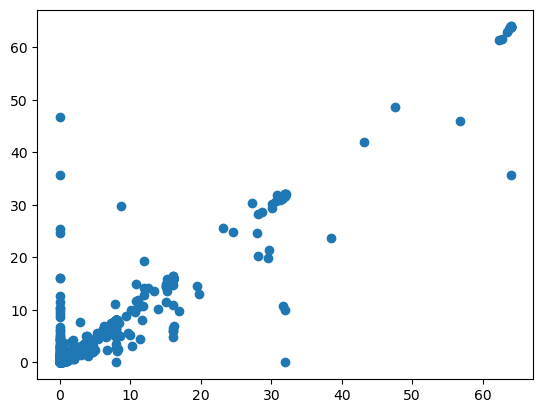

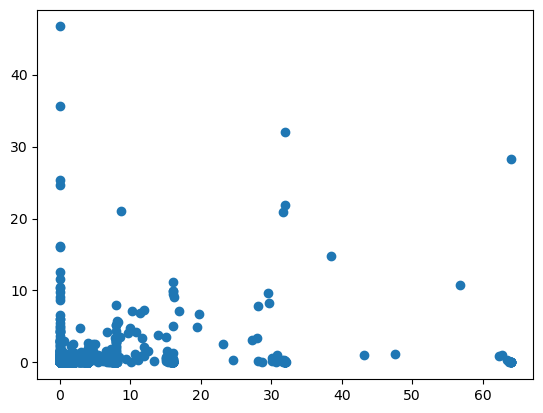

0.0
46.67978445297493


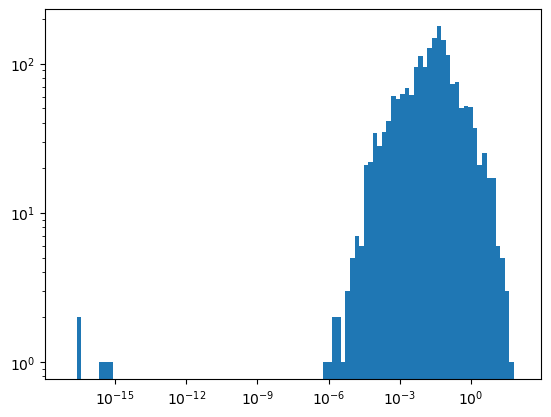

3.3105735615102105e-05
0.2464067951740799


In [26]:
import matplotlib.pyplot as plt
print(np.shape(y_true_test[1, :]))
plt.scatter(y_true_test[1, :], y_pred_test[1, :])
plt.show()

plt.scatter(y_true_test[1, :], np.abs(y_pred_test[1, :] - y_true_test[1, :]))
plt.show()

print(np.min(np.abs(y_pred_test[1, :] - y_true_test[1, :])))
print(np.max(np.abs(y_pred_test[1, :] - y_true_test[1, :])))
# logbins = np.logspace(np.log(np.min(np.abs(y_pred_test[1, :] - y_true_test[1, :]))), np.log(np.max(np.abs(y_pred_test[1, :] - y_true_test[1, :]))), 100)
logbins = np.logspace(-17, 2, 100)

plt.hist(np.abs(y_pred_test[1, :] - y_true_test[1, :]), bins = logbins)
plt.yscale('log')
plt.xscale('log')
plt.show()

print(np.median( np.abs(y_pred_test[1, :] - y_true_test[1, :])))
print(np.mean( np.abs(y_pred_test[1, :] - y_true_test[1, :])))


M2 errors - full precision:
  Median absolute: 0.00003311
  Min absolute: 0.00000000
  Max absolute: 46.67978445
  Mean absolute: 0.24640680


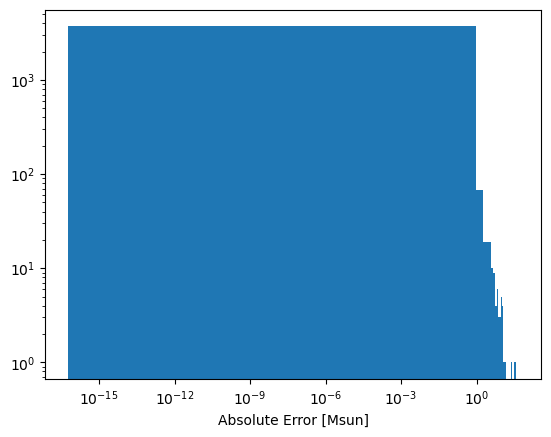

In [29]:
median_abs_error_m2_test = np.median( np.abs(y_pred_test[1, :] - y_true_test[1, :]))
pred_mass2_test = y_pred_test[1, :]
true_mass2_test =  y_true_test[1, :]
mean_abs_error_m2_test = np.mean( np.abs(y_pred_test[1, :] - y_true_test[1, :]))
print(f"M2 errors - full precision:")
print(f"  Median absolute: {median_abs_error_m2_test:.8f}")
print(f"  Min absolute: {np.min(np.abs(pred_mass2_test - true_mass2_test)):.8f}")
print(f"  Max absolute: {np.max(np.abs(pred_mass2_test - true_mass2_test)):.8f}")
print(f"  Mean absolute: {mean_abs_error_m2_test:.8f}")

# Also plot to verify
plt.hist(np.abs(pred_mass2_test - true_mass2_test), bins=50, log=True)
plt.xlabel('Absolute Error [Msun]')
plt.xscale('log')
plt.show()